# 15 — Calidad de curvas y mejora acotada por horizontes

**Pregunta:** ¿corregir pérdidas de información y adaptar el modelo al horizonte mejora H4–H5 sin deteriorar el conjunto?

Se parte de las proyecciones corregidas y de las bases oficiales. Se compara primero la misma arquitectura antes/después de calidad; luego se añade un bloque a la vez: separar H1–H2/H3–H5, memoria de doce semanas, historia de proyecciones y combinación sencilla. Las referencias de cuatro/ocho semanas y año anterior ya existían: no se presentan como novedades.

Los resultados de 2026 son desarrollo retrospectivo. La combinación fija sus pesos con predicciones temporales de noviembre–diciembre de 2025, antes de evaluar 2026. No se busca el mejor peso usando el resultado del ingeniero ni se promete ganar. Código autocontenido; ninguna celda ejecuta otro notebook ni importa módulos del proyecto.


In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()

from IPython.display import display
AUD=ROOT/'Notebooks/Proyecciones Teoricas Propias/resultados_todos_los_anios/auditoria_calidad'


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


## 1. Diagnóstico: dónde se concentra la desventaja

La prioridad se define por exceso de error absoluto del modelo frente al ingeniero en tallos. Los porcentajes de contribución no representan participación en producción. Se desglosa por horizonte, producto, variedad, origen y ruta; las diferencias pueden ser negativas cuando el modelo mejora al experto. Los casos repetidos por horizonte no son inventario físico.


In [3]:
actual=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet')
antes=pd.read_parquet(AUD/'modelo_antes_correccion.parquet')
llave=KEY+['origen','semana_objetivo','horizonte']
principal=actual.loc[actual.grupo_comparacion.eq('principal_estricta_nominal')].copy()
principal['error_modelo']=(principal.y-principal.Sistema_diario).abs()
principal['error_ingeniero']=(principal.y-principal.ingeniero).abs()
principal['exceso_error']=principal.error_modelo-principal.error_ingeniero
diagnosticos={}
for nombre,dims in [('Horizonte',['horizonte']),('Producto',['horizonte','producto']),('Variedad',['horizonte','producto','color','variedad']),('Semana',['horizonte','origen']),('Ruta',['horizonte','ruta_diaria'])]:
    t=principal.groupby(dims,dropna=False).agg(casos=('y','size'),real=('y','sum'),error_modelo=('error_modelo','sum'),error_ingeniero=('error_ingeniero','sum'),exceso_error=('exceso_error','sum')).reset_index()
    t['WAPE_modelo']=t.error_modelo/t.real; t['WAPE_ingeniero']=t.error_ingeniero/t.real
    diagnosticos[nombre]=t.sort_values('exceso_error',ascending=False)
    print(nombre);display(diagnosticos[nombre].head(12))


Horizonte


,horizonte,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
4,5.0,2925,37987912,8744941.917989,8129858.0,615083.917989,0.230203,0.214012
3,4.0,3045,39433648,8755619.652996,8245782.0,509837.652996,0.222034,0.209105
2,3.0,3166,40558233,8234190.001844,8239427.0,-5236.998156,0.203021,0.203151
0,1.0,3413,43114174,7235196.961431,7368295.0,-133098.038569,0.167815,0.170902
1,2.0,3289,42079208,7732966.228861,8114096.0,-381129.771139,0.183772,0.192829


Producto


,horizonte,producto,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
55,5.0,CARNATION,1073,6920208,1936117.20001,1606616.0,329501.20001,0.279777,0.232163
42,4.0,CARNATION,1118,7170958,1934315.783472,1664380.0,269935.783472,0.269743,0.2321
44,4.0,MINICARNATION,881,24071863,4886688.986196,4620191.0,266497.986196,0.203004,0.191933
5,1.0,MINICARNATION,979,26014524,4027494.854371,3780827.0,246667.854371,0.154817,0.145335
57,5.0,MINICARNATION,848,23190692,4884048.294976,4639314.0,244734.294976,0.210604,0.200051
59,5.0,SOLOMIO,348,4214399,883917.988766,775997.0,107920.988766,0.209738,0.18413
46,4.0,SOLOMIO,360,4398965,890114.876077,819253.0,70861.876077,0.202346,0.186238
29,3.0,CARNATION,1165,7379424,1784775.28281,1726596.0,58179.28281,0.241858,0.233974
31,3.0,MINICARNATION,913,24719696,4581404.654793,4536688.0,44716.654793,0.185334,0.183525
33,3.0,SOLOMIO,372,4545645,864527.015703,823395.0,41132.015703,0.190188,0.181139


Variedad


,horizonte,producto,color,variedad,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
556,5.0,MINICARNATION,HOT PINK,LORENZO,29,1582738,394368.900458,254570.0,139798.900458,0.249169,0.160842
437,4.0,MINICARNATION,HOT PINK,LORENZO,30,1647439,403421.440723,267065.0,136356.440723,0.244878,0.162109
328,3.0,MINICARNATION,PURPLE,EPSILON,31,1351514,281740.686373,155154.0,126586.686373,0.208463,0.1148
448,4.0,MINICARNATION,PURPLE,EPSILON,30,1322703,293227.360465,170041.0,123186.360465,0.221688,0.128556
567,5.0,MINICARNATION,PURPLE,EPSILON,29,1292577,295627.556791,198257.0,97370.556791,0.228712,0.153381
317,3.0,MINICARNATION,HOT PINK,LORENZO,31,1685723,369486.181831,273989.0,95497.181831,0.219186,0.162535
205,2.0,MINICARNATION,PURPLE,EPSILON,32,1389049,238559.012698,146971.0,91588.012698,0.171743,0.105807
82,1.0,MINICARNATION,PURPLE,EPSILON,33,1413035,221591.2336,142920.0,78671.2336,0.156819,0.101144
572,5.0,MINICARNATION,WHITE,WHISPER,29,771070,209573.607159,143216.0,66357.607159,0.271796,0.185737
516,5.0,CARNATION,LIGHT PINK,DONCEL,29,283300,116481.570663,53498.0,62983.570663,0.41116,0.188839


Semana


,horizonte,origen,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
33,2.0,2026-01-12,112,1496906,516191.737383,287602.0,228589.737383,0.344839,0.192131
3,1.0,2026-02-02,109,1380698,504028.682295,327272.0,176756.682295,0.365054,0.237034
36,2.0,2026-02-02,107,1317169,456166.065315,314091.0,142075.065315,0.346323,0.238459
96,4.0,2026-01-12,109,1380698,467249.52394,326138.0,141111.52394,0.338415,0.236212
149,5.0,2026-06-29,99,1232367,296963.657482,162437.0,134526.657482,0.24097,0.131809
99,4.0,2026-02-02,107,1280036,402011.775038,270220.0,131791.775038,0.314063,0.211103
68,3.0,2026-02-02,108,1215237,368382.519921,238537.0,129845.519921,0.303136,0.196288
108,4.0,2026-04-06,99,1268237,357583.940893,229391.0,128192.940893,0.281954,0.180874
92,3.0,2026-07-27,101,1364596,344257.118892,224058.0,120199.118892,0.252278,0.164194
119,4.0,2026-06-29,99,1122410,262179.007123,144784.0,117395.007123,0.233586,0.128994


Ruta


,horizonte,ruta_diaria,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
8,5.0,media4_con_diarios,2658,35332112,8124043.498711,7563128.0,560915.498711,0.229934,0.214058
6,4.0,media4_con_diarios,2778,36957942,8217713.092733,7706968.0,510745.092733,0.222353,0.208533
4,3.0,media4_con_diarios,2884,38112436,7751405.537817,7693740.0,57665.537817,0.203383,0.20187
9,5.0,teoria_con_diarios,267,2655800,620898.419279,566730.0,54168.419279,0.23379,0.213393
1,1.0,teoria_con_diarios,325,2428629,458337.613229,453209.0,5128.613229,0.188723,0.186611
7,4.0,teoria_con_diarios,267,2475706,537906.560264,538814.0,-907.439736,0.217274,0.217641
3,2.0,teoria_con_diarios,301,2410055,470095.440152,525319.0,-55223.559848,0.195056,0.21797
5,3.0,teoria_con_diarios,282,2445797,482784.464027,545687.0,-62902.535973,0.197394,0.223112
0,1.0,media4_con_diarios,3088,40685545,6776859.348202,6915086.0,-138226.651798,0.166567,0.169964
2,2.0,media4_con_diarios,2988,39669153,7262870.78871,7588777.0,-325906.21129,0.183086,0.191302


## 2. Memoria adicional con calendario y prueba temporal

Se añaden media de doce semanas, dispersión de ocho/doce, tendencia entre cuatro y doce y conteos observados de cuatro/ocho/doce. Se requieren al menos cuatro reportes en la nueva media de doce; los conteos exponen su cobertura. No se imputan semanas sin producción como cero. El clima y las tendencias diarias se conservan sin nuevas transformaciones para aislar este cambio.


In [4]:
f=pd.read_parquet(SALIDA/'modelo_diario/features_diarias.parquet')
diarias=[c for c in f if c not in KEY+['fecha']]
integrados=integrados.merge(f.rename(columns={'fecha':'origen'}),on=KEY+['origen'],how='left',validate='many_to_one')
base=pd.read_parquet(DESTINO/'produccion_clima_semanal.parquet')
def memoria_larga(base):
    calendario=pd.DataFrame({'origen':pd.date_range(base.semana_inicio.min(),base.semana_inicio.max()+pd.Timedelta(weeks=1),freq='W-MON')})
    z=base[KEY].drop_duplicates().merge(calendario,how='cross').merge(base[KEY+['semana_inicio','tallos_reales']].rename(columns={'semana_inicio':'origen'}),on=KEY+['origen'],how='left',validate='one_to_one').sort_values(KEY+['origen'])
    g=z.groupby(KEY).tallos_reales
    z['media_12']=g.transform(lambda s:s.shift(1).rolling(12,min_periods=4).mean())
    for v in [8,12]:z[f'desv_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=4).std())
    for v in [4,8,12]:z[f'reportes_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=1).count())
    return z.drop(columns='tallos_reales')
extra=memoria_larga(base)
extra_cols=[c for c in extra if c not in KEY+['origen']]
integrados=integrados.merge(extra,on=KEY+['origen'],how='left',validate='many_to_one')
integrados['tendencia_4_12']=integrados.media_4-integrados.media_12
extra_cols+=['tendencia_4_12']
alterada=base.copy(); corte_prueba=pd.Timestamp('2025-01-06')
alterada.loc[alterada.semana_inicio.ge(corte_prueba),'tallos_reales']+=1000000
prueba=memoria_larga(alterada)
pd.testing.assert_frame_equal(extra.loc[extra.origen.le(corte_prueba)].reset_index(drop=True),prueba.loc[prueba.origen.le(corte_prueba)].reset_index(drop=True))
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
datos['grupo_h']=np.where(datos.horizonte.le(2),'H1_H2','H3_H5')
elegibles=datos.merge(actual[llave],on=llave,how='inner',validate='one_to_one')
assert len(elegibles)==len(actual)
Xbase=X_columnas+diarias
Xteoria=X_teoria+diarias
historia=['teoria_previa_1','teoria_previa_2','revision_teoria']
display(datos[extra_cols].isna().mean().mul(100).to_frame('faltantes_pct'))
print('Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.')


,faltantes_pct
media_12,0.0
desv_8,0.0
desv_12,0.0
reportes_4,0.0
reportes_8,0.0
reportes_12,0.0
tendencia_4_12,0.0


Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.


## 3. Experimentos fijados antes de ejecutar sus resultados

`Separado`: misma arquitectura y variables de 14, con modelos para H1–H2 y H3–H5. `Memoria_larga`: añade únicamente el bloque de la sección anterior. `Revisiones`: añade historia de proyecciones a las dos rutas, conservando faltantes. Todos usan los mismos parámetros y reglas de entrenamiento de 14. El respaldo sigue corrigiendo media4 y la ruta completa corrige teoría. Si no hay suficientes casos completos de entrenamiento, se utiliza el respaldo y se informa; no se ajusta un modelo con datos futuros.


In [5]:
def predecir(train,test,etapa):
    extras=[] if etapa=='Separado' else extra_cols
    revisiones=historia if etapa=='Revisiones' else []
    xb=Xbase+extras+revisiones; xt=Xteoria+extras+revisiones
    pred=pd.Series(index=test.index,dtype=float)
    for grupo,tt in test.groupby('grupo_h'):
        tr=train.loc[train.grupo_h.eq(grupo)]
        modelo=crear_modelo('Boosting',xb)
        with threadpool_limits(limits=2):
            modelo.fit(tr[xb],tr.y-tr.media_4)
            pred.loc[tt.index]=np.maximum(0,tt.media_4+modelo.predict(tt[xb]))
            tc=tr.loc[tr.curva_completa]; target=tt.loc[tt.curva_completa]
            if len(tc)>=40 and len(target):
                modelo_t=crear_modelo('Boosting',xt)
                modelo_t.fit(tc[xt],tc.y-tc.teoria_modelo)
                pred.loc[target.index]=np.maximum(0,target.teoria_modelo+modelo_t.predict(target[xt]))
            elif len(target):print('Respaldo por pocos casos completos:',grupo,len(tc))
    assert pred.notna().all() and pred.ge(0).all()
    return pred

# Selección pequeña de combinación ANTES de 2026, con objetivos cerrados antes del 1 de enero.
validacion=datos.loc[datos.origen.ge('2025-11-03') & (datos.semana_objetivo+pd.Timedelta(days=7)).le(pd.Timestamp('2026-01-01'))].copy()
validacion['pred_modelo']=np.nan
for mes,te in validacion.groupby(validacion.origen.dt.to_period('M')):
    corte=te.origen.min(); tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    validacion.loc[te.index,'pred_modelo']=predecir(tr,te,'Revisiones')
    print('Validación de pesos',mes,flush=True)
pesos=[]; candidatos=[]
for grupo,g in validacion.groupby('grupo_h'):
    for referencia in ['media_4','teoria_con_respaldo']:
        ref=g.media_4 if referencia=='media_4' else g.teoria_modelo.where(g.curva_completa,g.media_4)
        for peso in [0,.25,.5,.75,1]:
            pred=peso*g.pred_modelo+(1-peso)*ref
            candidatos.append({'grupo':grupo,'referencia':referencia,'peso_modelo':peso,'WAPE_validacion':(g.y-pred).abs().sum()/g.y.sum(),'casos':len(g)})
seleccion=pd.DataFrame(candidatos)
# En empate se prefiere más peso del modelo y media4, sin consultar 2026.
pesos=seleccion.sort_values(['WAPE_validacion','peso_modelo','referencia'],ascending=[True,False,True]).groupby('grupo',sort=False).head(1).set_index('grupo')
display(pesos)
resultados=[]; controles=[]
for mes,te in elegibles.groupby(elegibles.origen.dt.to_period('M')):
    corte=te.origen.min(); tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    assert tr.semana_objetivo.max()+pd.Timedelta(days=7)<=corte
    r=te[llave+['y','grupo_h','curva_completa','media_4','teoria_modelo']].copy()
    for etapa in ['Separado','Memoria_larga','Revisiones']:
        r[etapa]=predecir(tr,te,etapa)
        print(mes,etapa,'completo',flush=True)
    r['Combinacion']=np.nan
    for grupo,g in r.groupby('grupo_h'):
        p=pesos.loc[grupo]
        ref=g.media_4 if p.referencia=='media_4' else g.teoria_modelo.where(g.curva_completa,g.media_4)
        r.loc[g.index,'Combinacion']=p.peso_modelo*g.Revisiones+(1-p.peso_modelo)*ref
    r['corte_entrenamiento_nuevo']=corte
    resultados.append(r)
    controles.append({'mes':str(mes),'corte':corte,'train':len(tr),'test':len(te),'max_objetivo_train':tr.semana_objetivo.max()})
resultado=pd.concat(resultados,ignore_index=True)
resultado=actual.merge(resultado.drop(columns=['y','media_4','teoria_modelo']),on=llave,how='left',validate='one_to_one')
resultado=resultado.merge(antes[llave+['Sistema_diario']].rename(columns={'Sistema_diario':'Antes_calidad'}),on=llave,how='left',validate='one_to_one')
assert len(resultado)==len(actual)
assert resultado.corte_entrenamiento_nuevo.eq(resultado.corte_diario).all()
resultado.to_parquet(DESTINO/'experimentos_horizontes_2026.parquet',index=False)


Validación de pesos 2025-11


Validación de pesos 2025-12


,referencia,peso_modelo,WAPE_validacion,casos
grupo,,,,
H1_H2,media_4,1.0,0.169911,1790
H3_H5,media_4,1.0,0.267814,1758


2026-01 Separado completo


2026-01 Memoria_larga completo


...

2026-07 Memoria_larga completo


2026-07 Revisiones completo


2026-08 Separado completo


2026-08 Memoria_larga completo


2026-08 Revisiones completo


## 4. Comparación sobre los mismos casos y conclusión calculada

Se separa el cambio por calidad (`Antes_calidad` → `Sistema_diario`) del cambio por modelado. Se informa conjunto, horizonte, ruta, mes y segmentos. La combinación no se ajusta de nuevo al ver estos errores. Un candidato con menor error en este periodo es una mejora retrospectiva que requiere confirmación futura; ninguna prueba estadística convierte datos ya examinados en un test intacto.


Se añade una sensibilidad con cinco horizontes completos por serie/origen y remuestreo emparejado por semana objetivo. Los intervalos son exploratorios y no corrigen la selección tras examinar resultados.

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Memoria_larga,15838.0,2510.254451,4502.662825,0.195682,459.261033
Combinacion,15838.0,2516.358640,4559.931397,0.196158,515.704061
Revisiones,15838.0,2516.358640,4559.931397,0.196158,515.704061
Separado,15838.0,2523.525414,4551.712293,0.196717,470.418402
ingeniero,15838.0,2531.724839,4403.875315,0.197356,1250.135497
Sistema_diario,15838.0,2569.952946,4641.154604,0.200336,513.101675
Antes_calidad,15838.0,2570.360189,4635.392756,0.200368,498.328171


n          MAE         RMSE      WAPE  \
horizonte metodo                                                       
1.0       Antes_calidad   3413.0  2119.443716  3844.286210  0.167779   
          Combinacion     3413.0  1981.365418  3534.085050  0.156849   
          Memoria_larga   3413.0  1975.061618  3510.873838  0.156350   
          Revisiones      3413.0  1981.365418  3534.085050  0.156849   
          Separado        3413.0  1952.705725  3465.112567  0.154580   
          Sistema_diario  3413.0  2119.893631  3844.751699  0.167815   
          ingeniero       3413.0  2158.891005  3727.656625  0.170902   
2.0       Antes_calidad   3289.0  2348.735304  4294.277125  0.183582   
          Combinacion     3289.0  2234.939441  4019.328057  0.174688   
          Memoria_larga   3289.0  2247.414722  4016.950062  0.175663   
          Revisiones      3289.0  2234.939441  4019.328057  0.174688   
          Separado        3289.0  2230.475879  4024.149177  0.174339   
          Sistema_diario  3289.0  2351.160301  4304.052800  0.183772   
          ingeniero       3289.0  2467.040438  4271.206690  0.192829   
3.0       Antes_calidad   3166.0  2603.342939  4710.658123  0.203219   
          Combinacion     3166.0  2624.260268  4779.726306  0.204851   
          Memoria_larga   3166.0  2607.315125  4676.979652  0.203529   
          Revisiones      3166.0  2624.260268  4779.726306  0.204851   
          Separado        3166.0  2640.689219  4758.244576  0.206134   
          Sistema_diario  3166.0  2600.818068  4715.453183  0.203021   
          ingeniero       3166.0  2602.472205  4469.143353  0.203151   
4.0       Antes_calidad   3045.0  2877.960767  5119.879948  0.222231   
          Combinacion     3045.0  2874.433084  5150.729565  0.221959   
          Memoria_larga   3045.0  2865.048281  5072.545518  0.221234   
          Revisiones      3045.0  2874.433084  5150.729565  0.221959   
          Separado        3045.0  2906.912335  5176.499112  0.224467   
          Sistema_diario  3045.0  2875.408753  5123.691629  0.222034   
          ingeniero       3045.0  2707.974384  4686.461443  0.209105   
5.0       Antes_calidad   2925.0  2989.790963  5201.722282  0.230208   
          Combinacion     2925.0  2967.492443  5244.261053  0.228492   
          Memoria_larga   2925.0  2955.878964  5175.723805  0.227597   
          Revisiones      2925.0  2967.492443  5244.261053  0.228492   
          Separado        2925.0  2993.164296  5249.874869  0.230468   
          Sistema_diario  2925.0  2989.723733  5211.436459  0.230203   
          ingeniero       2925.0  2779.438632  4878.863188  0.214012   

                                sesgo  
horizonte metodo                       
1.0       Antes_calidad    368.774586  
          Combinacion      235.070779  
          Memoria_larga    213.900247  
          Revisiones       235.070779  
          Separado         286.171947  
          Sistema_diario   390.932375  
          ingeniero        955.342807  
2.0       Antes_calidad    520.346656  
          Combinacion      441.158278  
          Memoria_larga    432.137811  
          Revisiones       441.158278  
          Separado         477.339583  
          Sistema_diario   536.493672  
          ingeniero       1045.368805  
3.0       Antes_calidad    485.285893  
          Combinacion      615.372670  
          Memoria_larga    512.134791  
          Revisiones       615.372670  
          Separado         516.419743  
          Sistema_diario   499.195923  
          ingeniero       1211.956096  
4.0       Antes_calidad    602.298239  
          Combinacion      709.748567  
          Memoria_larga    611.174084  
          Revisiones       709.748567  
          Separado         598.220918  
          Sistema_diario   613.165367  
          ingeniero       1466.321182  
5.0       Antes_calidad    530.618966  
          Combinacion      617.094190  
          Memoria_larga    560.680204  
          Revisiones       617.094190  
      

n          MAE         RMSE  \
ruta_diaria        metodo                                              
media4_con_diarios Antes_calidad   14396.0  2652.429275  4760.301755   
                   Combinacion     14396.0  2595.056565  4673.368592   
                   Memoria_larga   14396.0  2589.560443  4615.789044   
                   Revisiones      14396.0  2595.056565  4673.368592   
                   Separado        14396.0  2601.253856  4662.854616   
                   Sistema_diario  14396.0  2648.853311  4757.288043   
                   ingeniero       14396.0  2602.646499  4522.236284   
teoria_con_diarios Antes_calidad    1442.0  1751.035248  3125.752875   
                   Combinacion      1442.0  1730.689199  3215.028806   
                   Memoria_larga    1442.0  1718.514463  3158.446003   
                   Revisiones       1442.0  1730.689199  3215.028806   
                   Separado         1442.0  1747.534667  3239.420659   
                   Sistema_diario   1442.0  1782.262481  3262.475658   
                   ingeniero        1442.0  1823.688627  2974.335142   

                                       WAPE        sesgo  
ruta_diaria        metodo                                 
media4_con_diarios Antes_calidad   0.200173   490.790648  
                   Combinacion     0.195843   507.744674  
                   Memoria_larga   0.195428   451.524791  
                   Revisiones      0.195843   507.744674  
                   Separado        0.196311   459.384326  
                   Sistema_diario  0.199903   500.436255  
                   ingeniero       0.196416  1281.400736  
teoria_con_diarios Antes_calidad   0.203366   573.577950  
                   Combinacion     0.201003   595.165449  
                   Memoria_larga   0.199589   536.494687  
                   Revisiones      0.201003   595.165449  
                   Separado        0.202960   580.575514  
                   Sistema_diario  0.206993   639.545070  
                   ingeniero       0.211804   938.003467

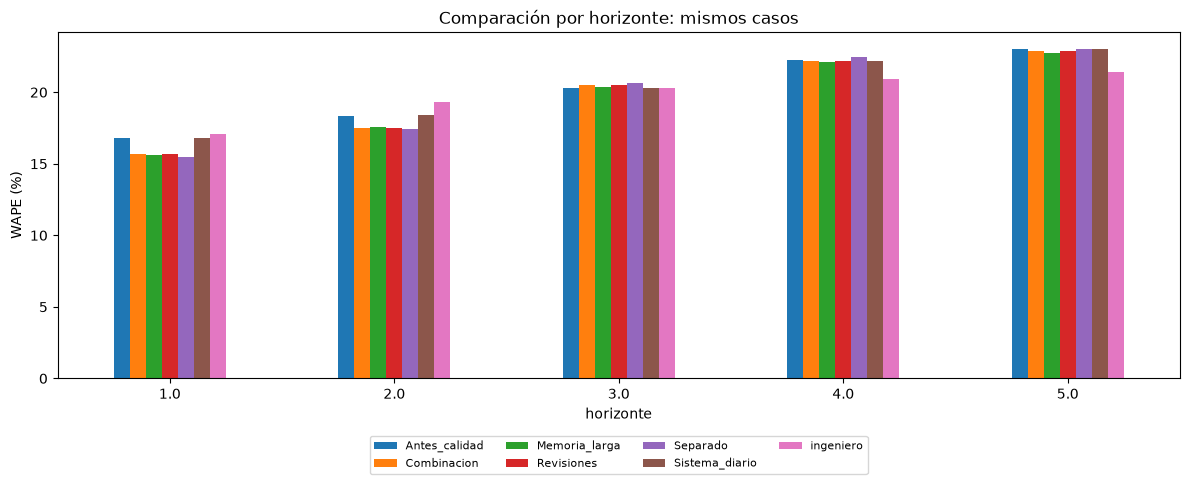

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Antes_calidad,14585.0,2653.558593,4754.136395,0.203107,532.132388
Combinacion,14585.0,2600.903664,4683.138393,0.199077,556.420322
Memoria_larga,14585.0,2594.393826,4622.586427,0.198579,498.713775
Revisiones,14585.0,2600.903664,4683.138393,0.199077,556.420322
Separado,14585.0,2608.545764,4672.264698,0.199662,508.866765
Sistema_diario,14585.0,2653.889214,4761.364709,0.203133,543.970699
ingeniero,14585.0,2616.041618,4523.993645,0.200236,1332.362770


,candidato,referencia,ventaja_pp,p025,p975
0,Sistema_diario,ingeniero,-0.298000,-1.716686,1.152692
1,Sistema_diario,Antes_calidad,0.003175,-0.046630,0.054232
2,Separado,ingeniero,0.063917,-1.374348,1.449957
3,Separado,Antes_calidad,0.365092,0.160802,0.552677
4,Memoria_larga,ingeniero,0.167369,-1.128963,1.489594
5,Memoria_larga,Antes_calidad,0.468543,0.182817,0.686383
6,Revisiones,ingeniero,0.119784,-1.199085,1.462873
7,Revisiones,Antes_calidad,0.420959,0.181621,0.656937
8,Combinacion,ingeniero,0.119784,-1.298691,1.384624
9,Combinacion,Antes_calidad,0.420959,0.194128,0.644127


Intervalos exploratorios por semana objetivo; ventaja positiva favorece al candidato. No corrigen selección retrospectiva ni toda la dependencia temporal.


Menor error retrospectivo entre candidatos: Memoria_larga
WAPE candidato: 19.568 %; ingeniero: 19.736 %
Validación futura: fijar candidato, parámetros y pesos antes del próximo periodo no examinado, archivar fecha real de emisión y evaluar H1–H5 sobre casos comunes. No sustituir al experto por esta selección retrospectiva.


In [6]:
metodos=['ingeniero','Antes_calidad','Sistema_diario','Separado','Memoria_larga','Revisiones','Combinacion']
d=resultado.loc[resultado.grupo_comparacion.eq('principal_estricta_nominal')].copy()
assert d[metodos].notna().all().all()
larga=d.melt(id_vars=llave+['y','ruta_diaria','grupo_h'],value_vars=metodos,var_name='metodo',value_name='prediccion')
def metricas(g):
    e=g.y-g.prediccion
    return pd.Series({'n':len(g),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'WAPE':e.abs().sum()/g.y.sum(),'sesgo':e.mean()})
resumen=larga.groupby('metodo').apply(metricas)
horizonte=larga.groupby(['horizonte','metodo']).apply(metricas)
ruta=larga.groupby(['ruta_diaria','metodo']).apply(metricas)
producto=larga.groupby(['producto','metodo']).apply(metricas)
variedad=larga.groupby(['producto','color','variedad','metodo']).apply(metricas)
mes=larga.groupby([larga.origen.dt.to_period('M').astype(str),'metodo']).apply(metricas)
display(resumen.sort_values('WAPE'));display(horizonte);display(ruta)
ax=horizonte.WAPE.unstack().mul(100).plot.bar(figsize=(12,5),rot=0,ylabel='WAPE (%)',title='Comparación por horizonte: mismos casos')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.15),ncol=4,fontsize=8);plt.tight_layout();plt.show()
# Sensibilidad al exigir H1–H5 completos y remuestreo semanal emparejado.
panelkeys=KEY+['origen']
balance=d.loc[d.groupby(panelkeys).horizonte.transform('nunique').eq(5)]
balance_largo=balance.melt(id_vars=llave+['y'],value_vars=metodos,var_name='metodo',value_name='prediccion')
sensibilidad=balance_largo.groupby('metodo').apply(metricas)
rng=np.random.default_rng(42); intervalos=[]
for candidato in ['Sistema_diario','Separado','Memoria_larga','Revisiones','Combinacion']:
    for referencia in ['ingeniero','Antes_calidad']:
        z=pd.DataFrame({'semana':d.semana_objetivo,'real':d.y,'ventaja':(d.y-d[referencia]).abs()-(d.y-d[candidato]).abs()}).groupby('semana').sum()
        indices=rng.integers(0,len(z),size=(1000,len(z)))
        muestras=100*z.ventaja.to_numpy()[indices].sum(axis=1)/z.real.to_numpy()[indices].sum(axis=1)
        intervalos.append({'candidato':candidato,'referencia':referencia,'ventaja_pp':100*z.ventaja.sum()/z.real.sum(),'p025':np.quantile(muestras,.025),'p975':np.quantile(muestras,.975)})
incertidumbre=pd.DataFrame(intervalos)
display(sensibilidad);display(incertidumbre)
print('Intervalos exploratorios por semana objetivo; ventaja positiva favorece al candidato. No corrigen selección retrospectiva ni toda la dependencia temporal.')
with pd.ExcelWriter(DESTINO/'resultados_experimentos_horizontes.xlsx') as writer:
    for name,t in [('Resumen',resumen),('Horizonte',horizonte),('Ruta',ruta),('Producto',producto),('Variedad',variedad),('Mes',mes),('Pesos_pre2026',pesos),('Validacion_pesos',seleccion),('Cortes',pd.DataFrame(controles))]:t.to_excel(writer,sheet_name=name)
    for name,t in diagnosticos.items():t.to_excel(writer,sheet_name='Diagnostico_'+name,index=False)
    sensibilidad.to_excel(writer,sheet_name='Panel_H1_H5')
    incertidumbre.to_excel(writer,sheet_name='Incertidumbre',index=False)
ganador=resumen.drop(index=['ingeniero','Antes_calidad']).WAPE.idxmin()
print('Menor error retrospectivo entre candidatos:',ganador)
print('WAPE candidato:',round(100*resumen.loc[ganador,'WAPE'],3),'%; ingeniero:',round(100*resumen.loc['ingeniero','WAPE'],3),'%')
print('Validación futura: fijar candidato, parámetros y pesos antes del próximo periodo no examinado, archivar fecha real de emisión y evaluar H1–H5 sobre casos comunes. No sustituir al experto por esta selección retrospectiva.')


## Continuación: clima, diario e interpretación

El notebook 19 compara clima y procedencia de curvas y fija el candidato con validación anterior a 2026. Diario 04 conserva esta referencia Memoria_larga; diario 05 distribuye el candidato de 19. El notebook 16 explica ese candidato por permutación. El 17 conserva el inventario de referencias y sus errores train/test por corte. Seguir el orden de la guía principal.

## 5. Lectura con clima actualizado

Se recalculó la arquitectura con clima válido hasta septiembre. Memoria_larga obtiene 19,57 % en el panel principal. La comparación específica con/sin clima, lluvia y curva local está en 19; su selección previa es Sin_clima. `Antes_calidad` conserva una ejecución histórica con clima anterior: su diferencia con los modelos actuales no aísla únicamente calidad de curvas. Las recuperaciones de datos siguen verificadas por la auditoría. Consultar las tablas ejecutadas y 19 para las conclusiones vigentes.